In [1]:
# ============================================================
# CELL 1 - Imports and Parameters
# ============================================================
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from torch.utils.data import DataLoader, Dataset

# Root folder that contains separate train/ and val/ subfolders of cnn_dataset CSV files.
DATASET_DIR = Path(r"C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed")
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
DATASET_GLOB = "*cnn_dataset*.csv"
# Folder where the trained PyTorch model and metadata will be saved.
OUTPUT_DIR = DATASET_DIR / "pytorch_ramp_cnn_outputs"

N_BINS = 25
# The model sees three aligned 1D channels per sample:
#   z   = profile elevation values
#   gap = bins filled by interpolation inside the observed extent
#   pad = bins that are just trailing zero-padding after last_valid_bin
CHANNELS = ["z", "gap", "pad"]
FEATURE_COLS = ["feat_kink_dz", "feat_kink_slope"]
USE_SCALAR_FEATURES = True
ACTIVE_FEATURE_COLS = FEATURE_COLS if USE_SCALAR_FEATURES else []
LABEL_MAP = {
    0: "RAMP",
    1: "CURB_NO_RAMP",
    4: "DEPRESSED_DITCH",
}
VALID_CLASS_IDS = sorted(LABEL_MAP.keys())
CLASS_TO_INDEX = {cls_id: idx for idx, cls_id in enumerate(VALID_CLASS_IDS)}
INDEX_TO_CLASS = {idx: cls_id for cls_id, idx in CLASS_TO_INDEX.items()}
INDEX_TO_LABEL = {idx: LABEL_MAP[cls_id] for cls_id, idx in CLASS_TO_INDEX.items()}

# Training hyperparameters.
BATCH_SIZE = 128
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 500
EARLY_STOPPING_PATIENCE = 100
DROPOUT = 0.1
RANDOM_SEED = 0
USE_Z_SCORE_ON_Z_CHANNEL = False
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 1
# Optional ramp-only augmentation applied after the train/val split.
# Augmentation is intentionally minute so profile geometry stays realistic.
ENABLE_RAMP_AUG = False
RAMP_AUG_FACTOR = 1
RAMP_NOISE_STD = 0.0025
RAMP_OFFSET_RANGE = 0.005
PLOT_RAMP_AUG_SAMPLES = 5
# Optional per-class caps applied right after loading the combined dataset.
# Use None to keep all rows for a class. Example: {"DEPRESSED_DITCH": 1000}
MAX_SAMPLES_PER_LABEL = {
    "RAMP": None,
    "CURB_NO_RAMP": None,
    "DEPRESSED_DITCH": None,
}
# Split mode options:
#   internal_train_split -> load files from TRAIN_DIR only, then split them internally
#   folder_holdout       -> use TRAIN_DIR as train and VAL_DIR as validation directly
SPLIT_MODE = "internal_train_split"

# Fraction of the dataset used for validation.
VAL_SIZE = 0.2

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=RANDOM_SEED):
    """Seed Python, NumPy, and PyTorch for repeatable experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dataset dir : {DATASET_DIR}")
print(f"Train dir   : {TRAIN_DIR}")
print(f"Val dir     : {VAL_DIR}")
print(f"Dataset glob: {DATASET_GLOB}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Device     : {device}")
print(f"Classes    : {INDEX_TO_LABEL}")
print(f"Use scalar features: {USE_SCALAR_FEATURES}")
print(f"Feature cols: {ACTIVE_FEATURE_COLS}")
print(f"Use focal loss: {USE_FOCAL_LOSS} (gamma={FOCAL_GAMMA})")
print(f"Per-class caps: {MAX_SAMPLES_PER_LABEL}")
print(f"Ramp augmentation enabled: {ENABLE_RAMP_AUG} | factor={RAMP_AUG_FACTOR} | noise_std={RAMP_NOISE_STD} | offset_range={RAMP_OFFSET_RANGE}")
print(f"Split mode: {SPLIT_MODE}")


Dataset dir : C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed
Train dir   : C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\train
Val dir     : C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\val
Dataset glob: *cnn_dataset*.csv
Output dir : C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\pytorch_ramp_cnn_outputs
Device     : cuda
Classes    : {0: 'RAMP', 1: 'CURB_NO_RAMP', 2: 'DEPRESSED_DITCH'}
Use scalar features: True
Feature cols: ['feat_kink_dz', 'feat_kink_slope']
Use focal loss: True (gamma=1)
Per-class caps: {'RAMP': None, 'CURB_NO_RAMP': None, 'DEPRESSED_DITCH': None}
Ramp augmentation enabled: False | factor=1 | noise_std=0.0025 | offset_range=0.005
Split mode: internal_train_split


In [2]:
# ============================================================
# CELL 2 - Load Dataset and Build Arrays
# ============================================================
# Discover dataset CSV files from the configured train/val folders.
train_dataset_files = sorted(TRAIN_DIR.glob(DATASET_GLOB))
val_dataset_files = sorted(VAL_DIR.glob(DATASET_GLOB))

if not train_dataset_files:
    raise FileNotFoundError(f"No dataset CSVs found in train dir {TRAIN_DIR} matching pattern {DATASET_GLOB!r}")
if SPLIT_MODE == 'folder_holdout' and not val_dataset_files:
    raise FileNotFoundError(f"SPLIT_MODE='folder_holdout' requires validation CSVs in {VAL_DIR}, but none were found.")

def load_dataset_frames(file_list):
    frames = []
    for csv_path in file_list:
        part = pd.read_csv(csv_path).copy()
        part = part.assign(dataset_csv_path=str(csv_path.resolve()), dataset_csv_name=csv_path.name)
        frames.append(part)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

train_df_raw = load_dataset_frames(train_dataset_files)
val_df_raw = load_dataset_frames(val_dataset_files) if SPLIT_MODE == 'folder_holdout' else pd.DataFrame()
df = train_df_raw.copy() if SPLIT_MODE == 'internal_train_split' else pd.concat([train_df_raw, val_df_raw], ignore_index=True)

z_cols = [f"z_{i:03d}" for i in range(N_BINS)]
gap_cols = [f"gap_{i:03d}" for i in range(N_BINS)]
pad_cols = [f"pad_{i:03d}" for i in range(N_BINS)]
required_cols = z_cols + gap_cols + pad_cols + ACTIVE_FEATURE_COLS + ["class_int", "label", "side", "s_m", "source_file", "dataset_csv_path"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing[:10]}{'...' if len(missing) > 10 else ''}")

# Keep only the three target classes used for the ramp classifier.
df = df[df["class_int"].isin(VALID_CLASS_IDS)].copy()

# Optionally cap how many samples are kept for each label.
# In folder_holdout mode, caps are applied only to the train folder data; validation stays untouched.
def apply_label_caps(frame, cap_map, seed):
    cap_records = []
    capped_frames = []
    for label_name, group in frame.groupby("label", sort=False):
        cap = cap_map.get(label_name, None)
        original_n = len(group)
        if cap is None or cap >= original_n:
            kept_group = group.copy()
            kept_n = original_n
        else:
            kept_group = group.sample(n=int(cap), random_state=seed).copy()
            kept_n = len(kept_group)
        capped_frames.append(kept_group)
        cap_records.append((label_name, original_n, kept_n, cap))
    out = pd.concat(capped_frames, ignore_index=True) if capped_frames else frame.copy()
    return out, cap_records

if SPLIT_MODE == 'internal_train_split':
    df, cap_records = apply_label_caps(df, MAX_SAMPLES_PER_LABEL, RANDOM_SEED)
else:
    train_df_raw, cap_records = apply_label_caps(train_df_raw, MAX_SAMPLES_PER_LABEL, RANDOM_SEED)
    df = pd.concat([train_df_raw, val_df_raw], ignore_index=True)

df["target_idx"] = df["class_int"].map(CLASS_TO_INDEX).astype(int)
if not train_df_raw.empty:
    train_df_raw = train_df_raw[train_df_raw["class_int"].isin(VALID_CLASS_IDS)].copy()
    train_df_raw["target_idx"] = train_df_raw["class_int"].map(CLASS_TO_INDEX).astype(int)
if not val_df_raw.empty:
    val_df_raw = val_df_raw[val_df_raw["class_int"].isin(VALID_CLASS_IDS)].copy()
    val_df_raw["target_idx"] = val_df_raw["class_int"].map(CLASS_TO_INDEX).astype(int)

# Precompute profile tensor for quick dataset-wide sanity checks.
z = df[z_cols].to_numpy(dtype=np.float32)
gap = df[gap_cols].to_numpy(dtype=np.float32)
pad = df[pad_cols].to_numpy(dtype=np.float32)
X = np.stack([z, gap, pad], axis=1)
# Scalar engineered features live in the same rows, so they stay aligned through all later splits.
X_feat = df[ACTIVE_FEATURE_COLS].to_numpy(dtype=np.float32)
# Class targets are stored as compact indices 0..num_classes-1 for CrossEntropyLoss.
y = df["target_idx"].to_numpy(dtype=np.int64)

print(f"Train dataset files discovered: {len(train_dataset_files):,}")
for p in train_dataset_files:
    print(f"  [train] {p}")
if val_dataset_files:
    print(f"Val dataset files discovered: {len(val_dataset_files):,}")
    for p in val_dataset_files:
        print(f"  [val]   {p}")
print()
print("Per-class cap summary:")
for label_name, original_n, kept_n, cap in cap_records:
    print(f"  {label_name}: original={original_n:,} kept={kept_n:,} cap={cap}")
print()
print(f"Samples kept: {len(df):,}")
print(f"Tensor shape : {X.shape}")
print(f"Feature shape: {X_feat.shape}")
print()
print("Class distribution:")
print(df["label"].value_counts().to_string())
print()
print("Dataset CSV contribution:")
print(df["dataset_csv_path"].value_counts().to_string())
print()
print("Source files:")
print(df["source_file"].value_counts().to_string())
df[["label", "class_int", "s_m", "side", "source_file", "dataset_csv_name"]].head()


Train dataset files discovered: 14
  [train] C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\train\cnn_dataset_z10_p1.csv
  [train] C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\train\cnn_dataset_z10_p2.csv
  [train] C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\train\cnn_dataset_z10_p4.csv
  [train] C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\train\cnn_dataset_z11_p1.csv
  [train] C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\train\cnn_dataset_z11_p2.csv
  [train] C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\train\cnn_dataset_z1_p1.csv
  [train] C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\train\cnn_dataset_z1_p2.csv
  [train] C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\train\cnn_dataset_z2

,label,class_int,s_m,side,source_file,dataset_csv_name
0,RAMP,0,2.0,LEFT,C:\Users\jianjing\Desktop\Fiseha\Ramp_Detectio...,cnn_dataset_z10_p1.csv
1,RAMP,0,2.4,LEFT,C:\Users\jianjing\Desktop\Fiseha\Ramp_Detectio...,cnn_dataset_z10_p1.csv
2,RAMP,0,2.6,LEFT,C:\Users\jianjing\Desktop\Fiseha\Ramp_Detectio...,cnn_dataset_z10_p1.csv
3,RAMP,0,2.8,LEFT,C:\Users\jianjing\Desktop\Fiseha\Ramp_Detectio...,cnn_dataset_z10_p1.csv
4,RAMP,0,3.0,LEFT,C:\Users\jianjing\Desktop\Fiseha\Ramp_Detectio...,cnn_dataset_z10_p1.csv


In [3]:
# ============================================================
# CELL 3 - Train/Val Split
# ============================================================
# Split logic operates in one of two modes controlled by SPLIT_MODE.
split_records = []

if SPLIT_MODE == "internal_train_split":
    train_mask = np.zeros(len(df), dtype=bool)
    val_mask = np.zeros(len(df), dtype=bool)
    for source_name, source_idx in df.groupby("source_file").groups.items():
        source_idx = np.asarray(list(source_idx), dtype=int)
        y_source = y[source_idx]
        source_size = len(source_idx)
        class_counts_source = np.bincount(y_source, minlength=len(VALID_CLASS_IDS))

        if source_size < 2:
            train_mask[source_idx] = True
            split_records.append((source_name, source_size, int(source_size), 0, "all_train_too_small"))
            continue

        min_class_count = int(class_counts_source[class_counts_source > 0].min()) if np.any(class_counts_source > 0) else 0
        val_count_target = max(1, int(round(source_size * VAL_SIZE)))

        if min_class_count >= 2 and len(np.unique(y_source)) >= 2 and val_count_target >= len(np.unique(y_source)):
            splitter = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=RANDOM_SEED)
            train_sub, val_sub = next(splitter.split(np.zeros(source_size), y_source))
            train_idx = source_idx[train_sub]
            val_idx = source_idx[val_sub]
            mode = "per_source_stratified"
        else:
            train_sub, val_sub = train_test_split(np.arange(source_size), test_size=VAL_SIZE, random_state=RANDOM_SEED)
            train_idx = source_idx[train_sub]
            val_idx = source_idx[val_sub]
            mode = "per_source_random_fallback"
        train_mask[train_idx] = True
        val_mask[val_idx] = True
        split_records.append((source_name, source_size, int(len(train_idx)), int(len(val_idx)), mode))

    train_df = df.loc[train_mask].copy()
    val_df = df.loc[val_mask].copy()
    split_mode = "internal split from train folder"
elif SPLIT_MODE == "folder_holdout":
    train_df = train_df_raw.copy()
    val_df = val_df_raw.copy()
    for csv_name in train_df['dataset_csv_name'].drop_duplicates().tolist():
        total = int((train_df['dataset_csv_name'] == csv_name).sum())
        split_records.append((csv_name, total, total, 0, 'folder_train'))
    for csv_name in val_df['dataset_csv_name'].drop_duplicates().tolist():
        total = int((val_df['dataset_csv_name'] == csv_name).sum())
        split_records.append((csv_name, total, 0, total, 'folder_val'))
    split_mode = "train folder vs val folder holdout"
else:
    raise ValueError(f"Unknown SPLIT_MODE={SPLIT_MODE!r}. Expected one of: internal_train_split, folder_holdout")

print(f"Split mode: {split_mode}")
print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")

print()
print("Split summary:")
for source_name, source_size, n_train, n_val, mode in split_records:
    print(f"  {source_name} | total={source_size} train={n_train} val={n_val} mode={mode}")
print()
print("Train source files:")
print(train_df["source_file"].drop_duplicates().to_list())
print()
print("Val source files:")
print(val_df["source_file"].drop_duplicates().to_list())
print()
print("Train dataset files:")
print(train_df["dataset_csv_name"].drop_duplicates().to_list())
print()
print("Val dataset files:")
print(val_df["dataset_csv_name"].drop_duplicates().to_list())
print()
print("Train class distribution:")
print(train_df["label"].value_counts().to_string())


Split mode: internal split from train folder
Train: 10,573
Val  : 2,651

Split summary:
  C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\01\segments\part1\traj_sidewalk_remapped.csv | total=1979 train=1583 val=396 mode=per_source_stratified
  C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\01\segments\part2\traj_sidewalk_remapped.csv | total=2238 train=1790 val=448 mode=per_source_stratified
  C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\02\segments\part1\traj_sidewalk_remapped.csv | total=257 train=205 val=52 mode=per_source_stratified
  C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\03\segments\part1\traj_sidewalk_remapped.csv | total=1152 train=921 val=231 mode=per_source_stratified
  C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\03\segments\part2\traj_sidewalk_remapped.csv | total=370 train=296 val=74 mode=per_source_stratified
  C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\03\segments\part3\traj_sidewalk_remapped.csv | total=206 train=164 val=42 mode=per_source_stratifie

In [4]:
# ============================================================
# CELL 3.5 - Finite-Safe Scalar Feature Imputation
# ============================================================
# Some manually corrected labels can have missing rule-based scalar metrics.
# Fill those values from train-set finite means before augmentation/tensor conversion.
train_df = train_df.copy()
val_df = val_df.copy()
feature_impute_values = {}
if not ACTIVE_FEATURE_COLS:
    print("Scalar features disabled; skipping scalar feature imputation.")

for col in ACTIVE_FEATURE_COLS:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")
    val_df[col] = pd.to_numeric(val_df[col], errors="coerce")

    train_values = train_df[col].to_numpy(dtype=np.float32)
    val_values = val_df[col].to_numpy(dtype=np.float32)
    train_finite = np.isfinite(train_values)
    val_finite = np.isfinite(val_values)

    impute_value = float(train_values[train_finite].mean()) if train_finite.any() else 0.0
    feature_impute_values[col] = impute_value

    missing_train = int((~train_finite).sum())
    missing_val = int((~val_finite).sum())
    if missing_train or missing_val:
        print(f"{col}: filled missing/non-finite values with train mean {impute_value:.6f} | train={missing_train} val={missing_val}")

    train_df.loc[~train_finite, col] = impute_value
    val_df.loc[~val_finite, col] = impute_value

if ACTIVE_FEATURE_COLS:
    train_feat_check = train_df[ACTIVE_FEATURE_COLS].to_numpy(dtype=np.float32)
    val_feat_check = val_df[ACTIVE_FEATURE_COLS].to_numpy(dtype=np.float32)
    if not np.isfinite(train_feat_check).all() or not np.isfinite(val_feat_check).all():
        raise ValueError("Non-finite scalar features remain after imputation.")

print(f"Scalar feature imputation values: {feature_impute_values}")


feat_kink_dz: filled missing/non-finite values with train mean 0.088585 | train=51 val=17
feat_kink_slope: filled missing/non-finite values with train mean 0.270330 | train=51 val=17
Scalar feature imputation values: {'feat_kink_dz': 0.088584765791893, 'feat_kink_slope': 0.27032995223999023}


In [5]:
# ============================================================
# CELL 4 - Ramp Augmentation (Train Only)
# ============================================================
# Validation remains untouched. Only training RAMP rows are duplicated with tiny perturbations.
train_df = train_df.copy().reset_index(drop=True)
val_df = val_df.copy().reset_index(drop=True)
train_df["is_augmented"] = 0
val_df["is_augmented"] = 0
train_df["aug_parent_id"] = np.arange(len(train_df))
val_df["aug_parent_id"] = -1

def augment_ramp_rows(train_df, z_cols, random_seed=RANDOM_SEED):
    """Create minute augmented copies of training RAMP rows.

    Only z_* values inside the valid region are perturbed. gap_* and pad_* are left unchanged.
    """
    if (not ENABLE_RAMP_AUG) or RAMP_AUG_FACTOR <= 0:
        return train_df.copy(), pd.DataFrame()

    rng = np.random.default_rng(random_seed)
    ramp_df = train_df[train_df["label"] == "RAMP"].copy()
    aug_rows = []

    for _, row in ramp_df.iterrows():
        parent_id = int(row["aug_parent_id"])
        last_valid_bin = int(row["last_valid_bin"])
        valid_len = last_valid_bin + 1
        if valid_len <= 0:
            continue

        base_z = row[z_cols].to_numpy(dtype=float)
        for aug_id in range(RAMP_AUG_FACTOR):
            z_aug = base_z.copy()
            offset = rng.uniform(-RAMP_OFFSET_RANGE, RAMP_OFFSET_RANGE)
            noise = rng.normal(0.0, RAMP_NOISE_STD, size=valid_len)
            z_aug[:valid_len] = z_aug[:valid_len] + offset + noise
            z_aug[valid_len:] = 0.0

            new_row = row.copy()
            for i, col in enumerate(z_cols):
                new_row[col] = float(z_aug[i])
            new_row["is_augmented"] = 1
            new_row["aug_parent_id"] = parent_id
            aug_rows.append(new_row)

    aug_df = pd.DataFrame(aug_rows)
    if aug_df.empty:
        return train_df.copy(), aug_df

    train_df_final = pd.concat([train_df, aug_df], ignore_index=True)
    train_df_final = train_df_final.sample(frac=1.0, random_state=random_seed).reset_index(drop=True)
    return train_df_final, aug_df

train_df_final, ramp_aug_df = augment_ramp_rows(train_df, z_cols)
val_df_final = val_df.copy()

print(f"Original train rows: {len(train_df):,}")
print(f"Original train RAMP rows: {(train_df['label'] == 'RAMP').sum():,}")
print(f"Augmented RAMP rows added: {len(ramp_aug_df):,}")
print(f"Final train rows: {len(train_df_final):,}")
print()
print("Final train class distribution:")
print(train_df_final['label'].value_counts().to_string())

v_axis = np.arange(N_BINS) * 0.08
if ENABLE_RAMP_AUG and not ramp_aug_df.empty and PLOT_RAMP_AUG_SAMPLES > 0:
    plot_parents = ramp_aug_df['aug_parent_id'].drop_duplicates().to_numpy()[:PLOT_RAMP_AUG_SAMPLES]
    n_plot = len(plot_parents)
    fig, axes = plt.subplots(n_plot, 1, figsize=(12, 3.5 * n_plot), sharex=True)
    if n_plot == 1:
        axes = [axes]

    for ax, parent_id in zip(axes, plot_parents):
        orig_row = train_df[train_df['aug_parent_id'] == parent_id].iloc[0]
        aug_row = ramp_aug_df[ramp_aug_df['aug_parent_id'] == parent_id].iloc[0]
        orig_z = orig_row[z_cols].to_numpy(dtype=float)
        aug_z = aug_row[z_cols].to_numpy(dtype=float)
        last_valid_bin = int(orig_row['last_valid_bin'])
        valid_end_v = (last_valid_bin + 1) * 0.08 if last_valid_bin >= 0 else 0.0
        z_orig_plot = np.full(N_BINS, np.nan, dtype=float)
        z_aug_plot = np.full(N_BINS, np.nan, dtype=float)
        if last_valid_bin >= 0:
            z_orig_plot[: last_valid_bin + 1] = orig_z[: last_valid_bin + 1]
            z_aug_plot[: last_valid_bin + 1] = aug_z[: last_valid_bin + 1]
            ax.axvspan(0.0, valid_end_v, color='orange', alpha=0.10, label='valid extent')
        ax.plot(v_axis, z_orig_plot, lw=1.8, label='original ramp')
        ax.plot(v_axis, z_aug_plot, lw=1.4, ls='--', label='augmented ramp')
        ax.set_title(f"RAMP augmentation | parent_id={parent_id} | s_m={orig_row['s_m']:.3f} | side={orig_row['side']}")
        ax.set_ylabel('z (m)')
        ax.grid(True)
        ax.legend(fontsize=8)

    axes[-1].set_xlabel('v (m)')
    plt.tight_layout()
    plt.show()


Original train rows: 10,573
Original train RAMP rows: 1,395
Augmented RAMP rows added: 0
Final train rows: 10,573

Final train class distribution:
label
CURB_NO_RAMP       6884
DEPRESSED_DITCH    2294
RAMP               1395


In [6]:
# ============================================================
# CELL 4 - Dataset, Normalization, and DataLoaders
# ============================================================
def df_to_arrays(frame, z_cols, gap_cols, pad_cols, feature_cols):
    """Convert a dataframe subset into profile tensors, feature vectors, and targets."""
    z_arr = frame[z_cols].to_numpy(dtype=np.float32)
    gap_arr = frame[gap_cols].to_numpy(dtype=np.float32)
    pad_arr = frame[pad_cols].to_numpy(dtype=np.float32)
    X_arr = np.stack([z_arr, gap_arr, pad_arr], axis=1)
    X_feat_arr = frame[feature_cols].to_numpy(dtype=np.float32)
    y_arr = frame['target_idx'].to_numpy(dtype=np.int64)
    return X_arr, X_feat_arr, y_arr

X_train, X_train_feat, y_train = df_to_arrays(train_df_final, z_cols, gap_cols, pad_cols, ACTIVE_FEATURE_COLS)
X_val, X_val_feat, y_val = df_to_arrays(val_df_final, z_cols, gap_cols, pad_cols, ACTIVE_FEATURE_COLS)

# Normalize only the z channel using train-set statistics.
# gap/pad are already binary indicators and should stay in their original scale.
if USE_Z_SCORE_ON_Z_CHANNEL:
    z_train = X_train[:, 0, :]
    z_mean = float(z_train.mean())
    z_std = float(z_train.std())
    if z_std < 1e-8:
        z_std = 1.0
else:
    z_mean = 0.0
    z_std = 1.0

# Normalize engineered scalar features separately using train-set statistics only.
if USE_SCALAR_FEATURES:
    feat_mean = X_train_feat.mean(axis=0).astype(np.float32)
    feat_std = X_train_feat.std(axis=0).astype(np.float32)
    feat_std[feat_std < 1e-8] = 1.0
else:
    feat_mean = np.zeros(0, dtype=np.float32)
    feat_std = np.ones(0, dtype=np.float32)

# Inverse-frequency weighting gives more importance to minority classes during optimization.
class_counts = np.bincount(y_train, minlength=len(VALID_CLASS_IDS))
class_weights = class_counts.sum() / np.maximum(class_counts, 1)
class_weights = class_weights / class_weights.mean()
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

class RampProfileDataset(Dataset):
    """Wrap the profile arrays so PyTorch DataLoader can iterate over them in mini-batches.

    The z channel is normalized here once up front. gap/pad remain binary channels.
    Engineered feature vectors are normalized separately with their own train-set stats.
    """
    def __init__(self, X, X_feat, y, z_mean, z_std, feat_mean, feat_std):
        self.X = X.copy()
        self.X[:, 0, :] = (self.X[:, 0, :] - z_mean) / z_std
        self.X_feat = X_feat.copy()
        self.X_feat = (self.X_feat - feat_mean) / feat_std
        self.y = y.copy()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.X_feat[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.long),
        )

train_ds = RampProfileDataset(X_train, X_train_feat, y_train, z_mean, z_std, feat_mean, feat_std)
val_ds = RampProfileDataset(X_val, X_val_feat, y_val, z_mean, z_std, feat_mean, feat_std)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"z_mean={z_mean:.6f}, z_std={z_std:.6f}")
print(f"feat_mean={feat_mean}")
print(f"feat_std={feat_std}")
print(f"Class weights: {class_weights}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


z_mean=0.000000, z_std=1.000000
feat_mean=[0.08858477 0.27032995]
feat_std=[0.04423176 0.14158383]
Class weights: [1.6567703  0.33573425 1.00749545]
Train batches: 83 | Val batches: 21


In [7]:
# ============================================================
# CELL 5 - PyTorch 1D CNN Model
# ============================================================
class SpatialAttention1d(nn.Module):
    """Learns a soft weight over the length dimension.
    
    Squeezes channels → produces one attention score per position →
    multiplies back into the feature map so informative positions
    contribute more to the global average pool.
    """
    def __init__(self, in_ch, reduction=8):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Conv1d(in_ch, in_ch // reduction, kernel_size=1),
            nn.LeakyReLU(0.1),
            nn.Conv1d(in_ch // reduction, 1, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # x: (batch, 128, 48)
        w = self.attn(x)        # → (batch, 1, 48)
        return x * w            # broadcast across channels
    

class FocalLoss(nn.Module):
    """Multiclass focal loss for imbalanced classification.

    This wraps cross-entropy with an extra factor (1 - pt)^gamma so the model
    focuses more on hard / misclassified examples. Optional class weights can
    still be passed in to bias the loss toward minority classes.
    """
    def __init__(self, gamma=2.0, weight=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction


    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

class RampCNN(nn.Module):
    """Simple 1D CNN for station-side profile classification.

    Architecture:
      input (3 x 192)
      -> three Conv1d blocks with BatchNorm + LeakyReLU
      -> global average pooling
      -> small dense classifier head

    This is intentionally compact to reduce overfitting on a small corridor dataset.
    """
    def __init__(self, in_channels=3, num_features=2, num_classes=3, dropout=DROPOUT):
        super().__init__()
        self.use_scalar_features = num_features > 0
        self.attn = SpatialAttention1d(128, reduction=8)
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding="same"),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding="same"),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, kernel_size=3, padding="same"),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.profile_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
        )
        if self.use_scalar_features:
            self.feature_head = nn.Sequential(
                nn.Linear(num_features, 16),
                nn.LeakyReLU(0.1),
            )
            classifier_in = 64 + 16
        else:
            self.feature_head = None
            classifier_in = 64
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, 64),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x, x_feat):
        x = self.features(x)
        # x = self.attn(x)
        x = self.pool(x)
        x = self.profile_head(x)
        if self.use_scalar_features:
            x_feat = self.feature_head(x_feat)
            x = torch.cat([x, x_feat], dim=1)
        x = self.classifier(x)
        return x

model = RampCNN(in_channels=len(CHANNELS), num_features=len(ACTIVE_FEATURE_COLS), num_classes=len(VALID_CLASS_IDS)).to(device)
# Weighted cross-entropy is the default. Focal loss can be enabled to put
# more emphasis on hard / minority examples when plain CE saturates.
if USE_FOCAL_LOSS:
    criterion = FocalLoss(gamma=FOCAL_GAMMA, weight=class_weights_t)
    print(f"Using focal loss with gamma={FOCAL_GAMMA}")
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    print("Using weighted cross-entropy loss")
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

print(model)


Using focal loss with gamma=1
RampCNN(
  (attn): SpatialAttention1d(
    (attn): Sequential(
      (0): Conv1d(128, 16, kernel_size=(1,), stride=(1,))
      (1): LeakyReLU(negative_slope=0.1)
      (2): Conv1d(16, 1, kernel_size=(1,), stride=(1,))
      (3): Sigmoid()
    )
  )
  (features): Sequential(
    (0): Conv1d(3, 64, kernel_size=(7,), stride=(1,), padding=same)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=same)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=same)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=Tru

In [8]:
# ============================================================
# CELL 6 - Train the Model
# ============================================================
def run_epoch(model, loader, criterion, optimizer=None):
    """Run one full pass over a dataloader.

    If optimizer is provided, the model trains and updates weights.
    If optimizer is None, the model runs in evaluation mode only.
    Returns average loss, accuracy, and macro F1 for the whole loader.
    """
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    total_correct = 0
    total_count = 0
    all_preds = []
    all_targets = []

    for xb, xb_feat, yb in loader:
        xb = xb.to(device)
        xb_feat = xb_feat.to(device)
        yb = yb.to(device)

        with torch.set_grad_enabled(train_mode):
            logits = model(xb, xb_feat)
            loss = criterion(logits, yb)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        preds = logits.argmax(dim=1)
        total_correct += int((preds == yb).sum().item())
        total_count += int(xb.size(0))
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(yb.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds, axis=0)
    y_true = np.concatenate(all_targets, axis=0)
    macro_f1 = f1_score(y_true, y_pred, labels=list(range(len(VALID_CLASS_IDS))), average="macro", zero_division=0)
    return total_loss / total_count, total_correct / total_count, macro_f1

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_f1": [], "val_f1": []}
best_val_loss = float("inf")
best_val_f1 = -float("inf")
best_state = None
best_epoch = -1
epochs_without_improve = 0

# Standard training loop with validation after every epoch.
# The best checkpoint is chosen using validation macro F1 instead of validation loss.
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

    # Save the best model state seen so far.
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1
        if epochs_without_improve >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model from epoch {best_epoch} with val_f1={best_val_f1:.4f} and val_loss={best_val_loss:.4f}")


Epoch 01 | train_loss=0.3956 train_acc=0.4808 train_f1=0.3495 | val_loss=0.3868 val_acc=0.5873 val_f1=0.4041
Epoch 02 | train_loss=0.3233 train_acc=0.5969 train_f1=0.5317 | val_loss=0.3274 val_acc=0.6005 val_f1=0.4165
Epoch 03 | train_loss=0.2518 train_acc=0.7575 train_f1=0.7353 | val_loss=0.2246 val_acc=0.7605 val_f1=0.7315
Epoch 04 | train_loss=0.2018 train_acc=0.7659 train_f1=0.7422 | val_loss=0.1912 val_acc=0.7722 val_f1=0.7476
Epoch 05 | train_loss=0.1734 train_acc=0.7845 train_f1=0.7671 | val_loss=0.2215 val_acc=0.7359 val_f1=0.6803
Epoch 06 | train_loss=0.1520 train_acc=0.7963 train_f1=0.7824 | val_loss=0.1598 val_acc=0.7971 val_f1=0.7786
Epoch 07 | train_loss=0.1371 train_acc=0.8037 train_f1=0.7928 | val_loss=0.1346 val_acc=0.8129 val_f1=0.8057
Epoch 08 | train_loss=0.1222 train_acc=0.8160 train_f1=0.8091 | val_loss=0.1197 val_acc=0.8235 val_f1=0.8190
Epoch 09 | train_loss=0.1101 train_acc=0.8247 train_f1=0.8180 | val_loss=0.1079 val_acc=0.8269 val_f1=0.8214
Epoch 10 | train_lo

Validation accuracy: 0.9464
Validation macro F1: 0.9281

                 precision    recall  f1-score   support

           RAMP     0.8506    0.9600    0.9020       350
   CURB_NO_RAMP     0.9915    0.9443    0.9673      1725
DEPRESSED_DITCH     0.8874    0.9444    0.9151       576

       accuracy                         0.9464      2651
      macro avg     0.9099    0.9496    0.9281      2651
   weighted avg     0.9503    0.9464    0.9474      2651



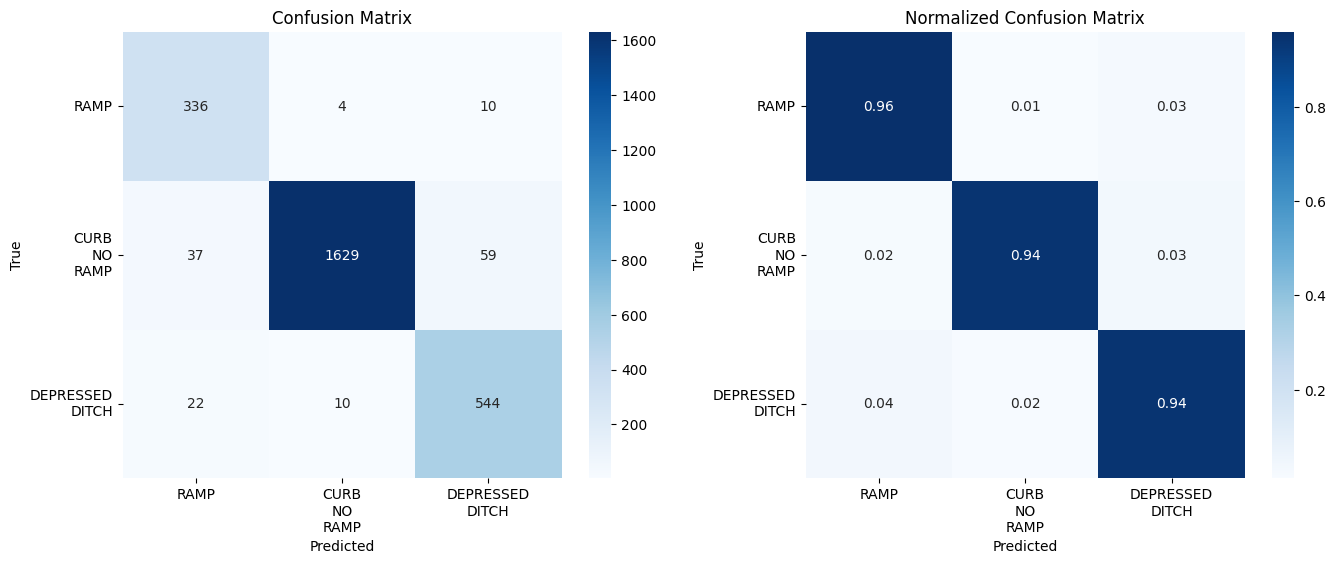

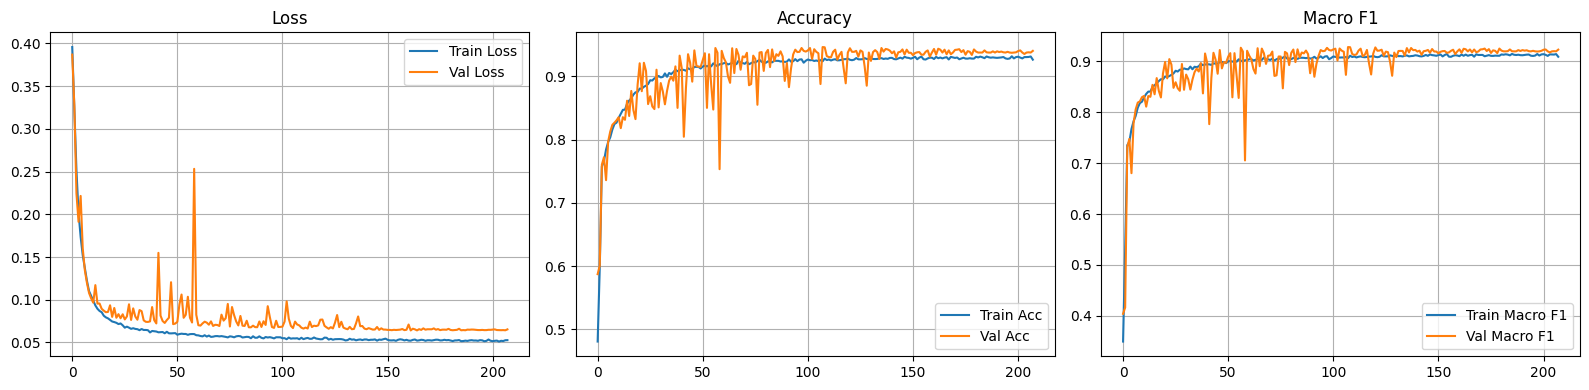

In [9]:
# ============================================================
# CELL 7 - Evaluate on Validation Set
# ============================================================
# Evaluate the final selected model on the validation split.
# You said your real held-out zones are elsewhere, so this notebook now uses only train/val.
model.eval()
all_logits = []
all_targets = []

with torch.no_grad():
    for xb, xb_feat, yb in val_loader:
        xb = xb.to(device)
        xb_feat = xb_feat.to(device)
        logits = model(xb, xb_feat)
        all_logits.append(logits.cpu().numpy())
        all_targets.append(yb.numpy())

logits = np.concatenate(all_logits, axis=0)
y_true = np.concatenate(all_targets, axis=0)
y_pred = logits.argmax(axis=1)
# Force sklearn to report all configured classes even if one class is absent in this validation split.
eval_labels = list(range(len(INDEX_TO_LABEL)))
label_names = [INDEX_TO_LABEL[i] for i in eval_labels]
display_label_names = [name.replace("_", "\n") for name in label_names]

val_eval_acc = (y_pred == y_true).mean()
val_eval_f1 = f1_score(y_true, y_pred, labels=eval_labels, average="macro", zero_division=0)
print(f"Validation accuracy: {val_eval_acc:.4f}")
print(f"Validation macro F1: {val_eval_f1:.4f}")
print()
print(classification_report(y_true, y_pred, labels=eval_labels, target_names=label_names, digits=4, zero_division=0))

# Raw and row-normalized confusion matrices are both useful:
#   raw counts   -> how many samples are being confused
#   normalized   -> recall-style view per true class
cm = confusion_matrix(y_true, y_pred, labels=eval_labels)
cm_norm = confusion_matrix(y_true, y_pred, labels=eval_labels, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=display_label_names, yticklabels=display_label_names, ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=0, labelsize=10)
axes[0].tick_params(axis="y", rotation=0, labelsize=10)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=display_label_names, yticklabels=display_label_names, ax=axes[1])
axes[1].set_title("Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=0, labelsize=10)
axes[1].tick_params(axis="y", rotation=0, labelsize=10)

plt.tight_layout(pad=2.0)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history["train_f1"], label="Train Macro F1")
axes[2].plot(history["val_f1"], label="Val Macro F1")
axes[2].set_title("Macro F1")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


GT=CURB_NO_RAMP in val     : 1,725
Misclassified CURB_NO_RAMP : 96


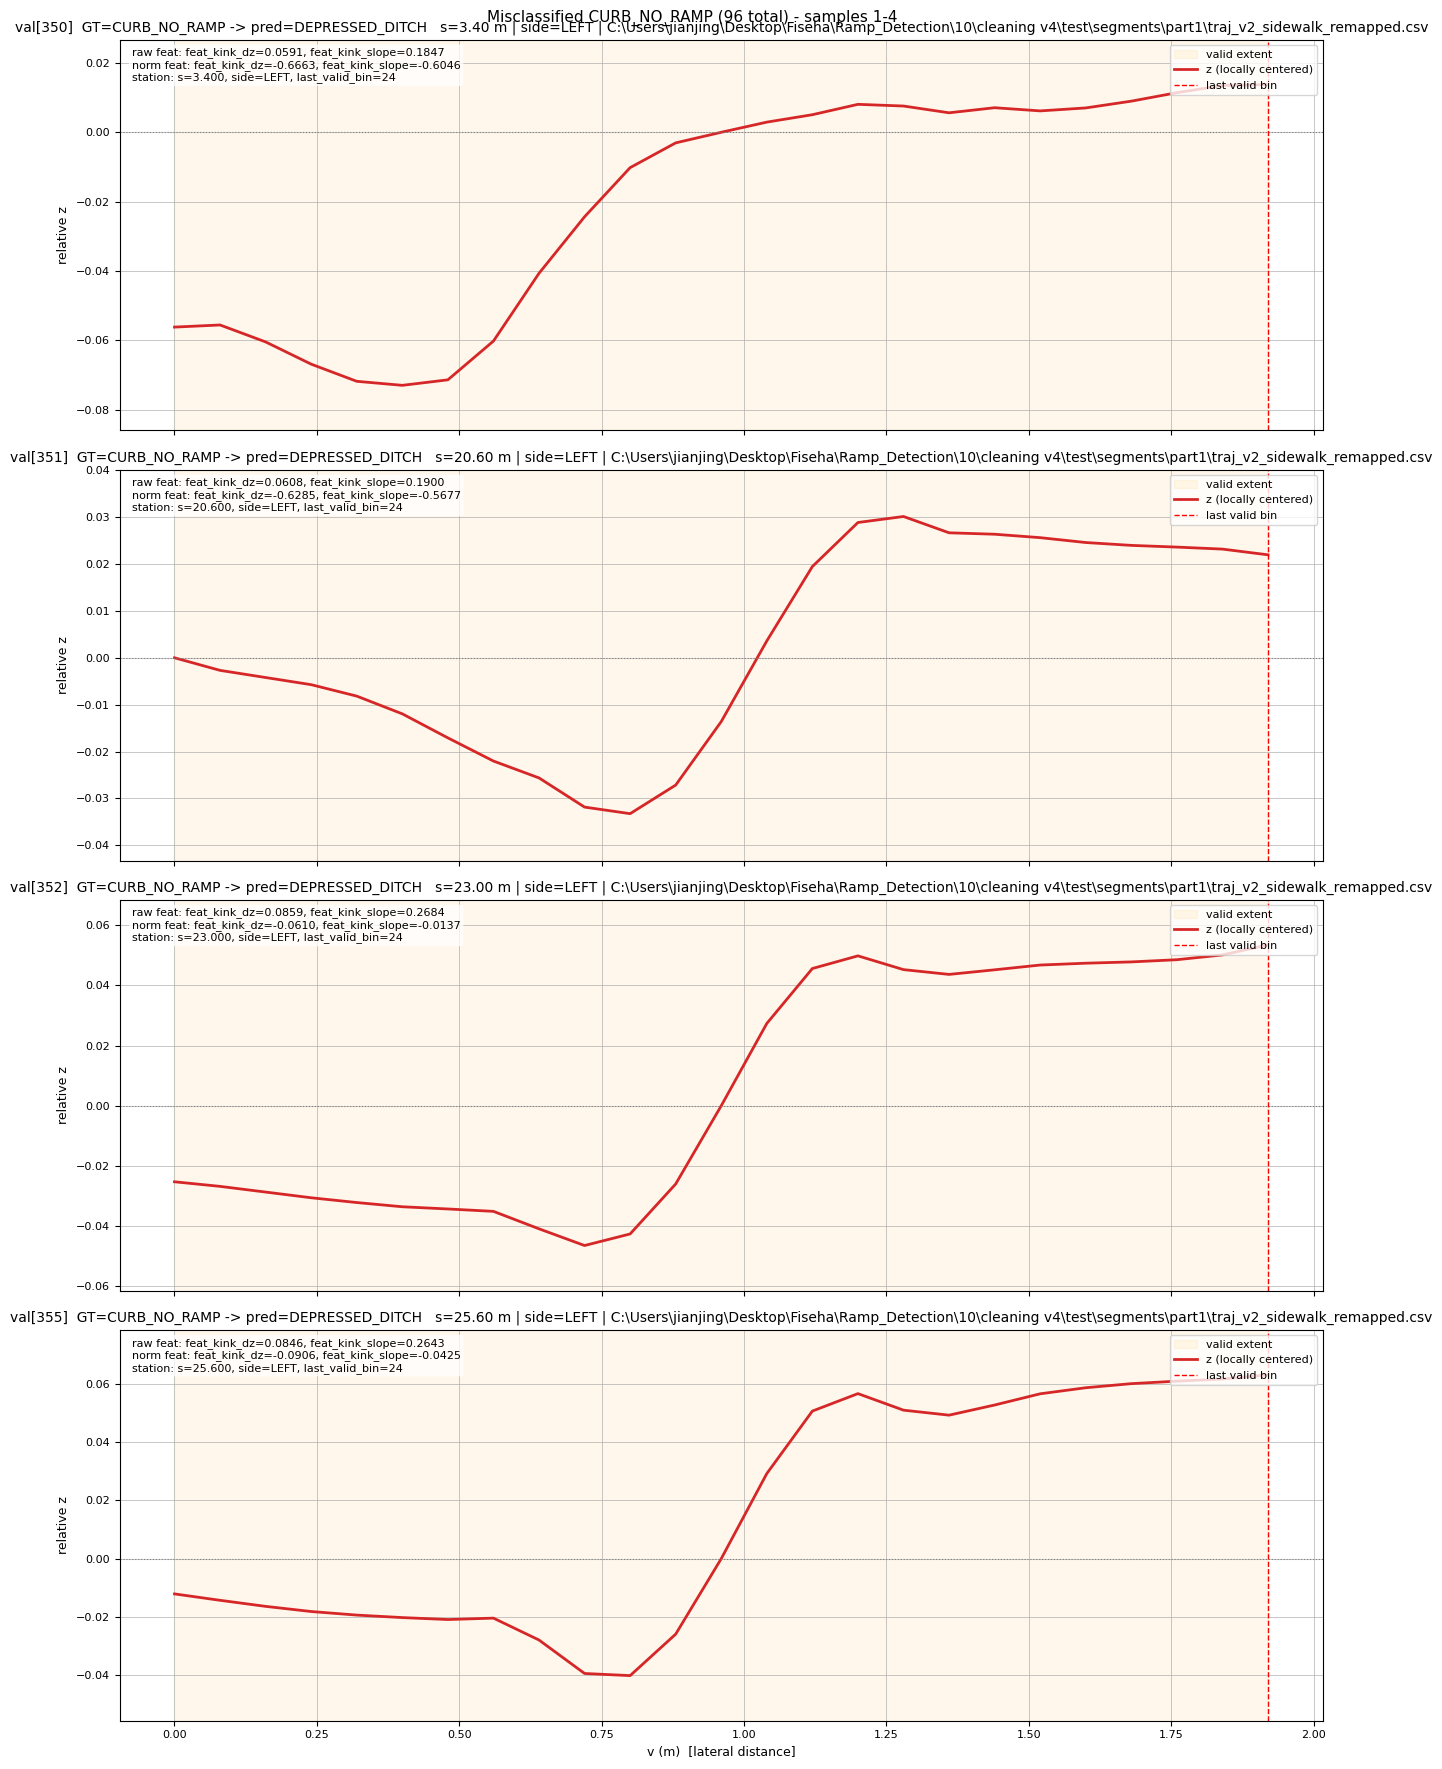

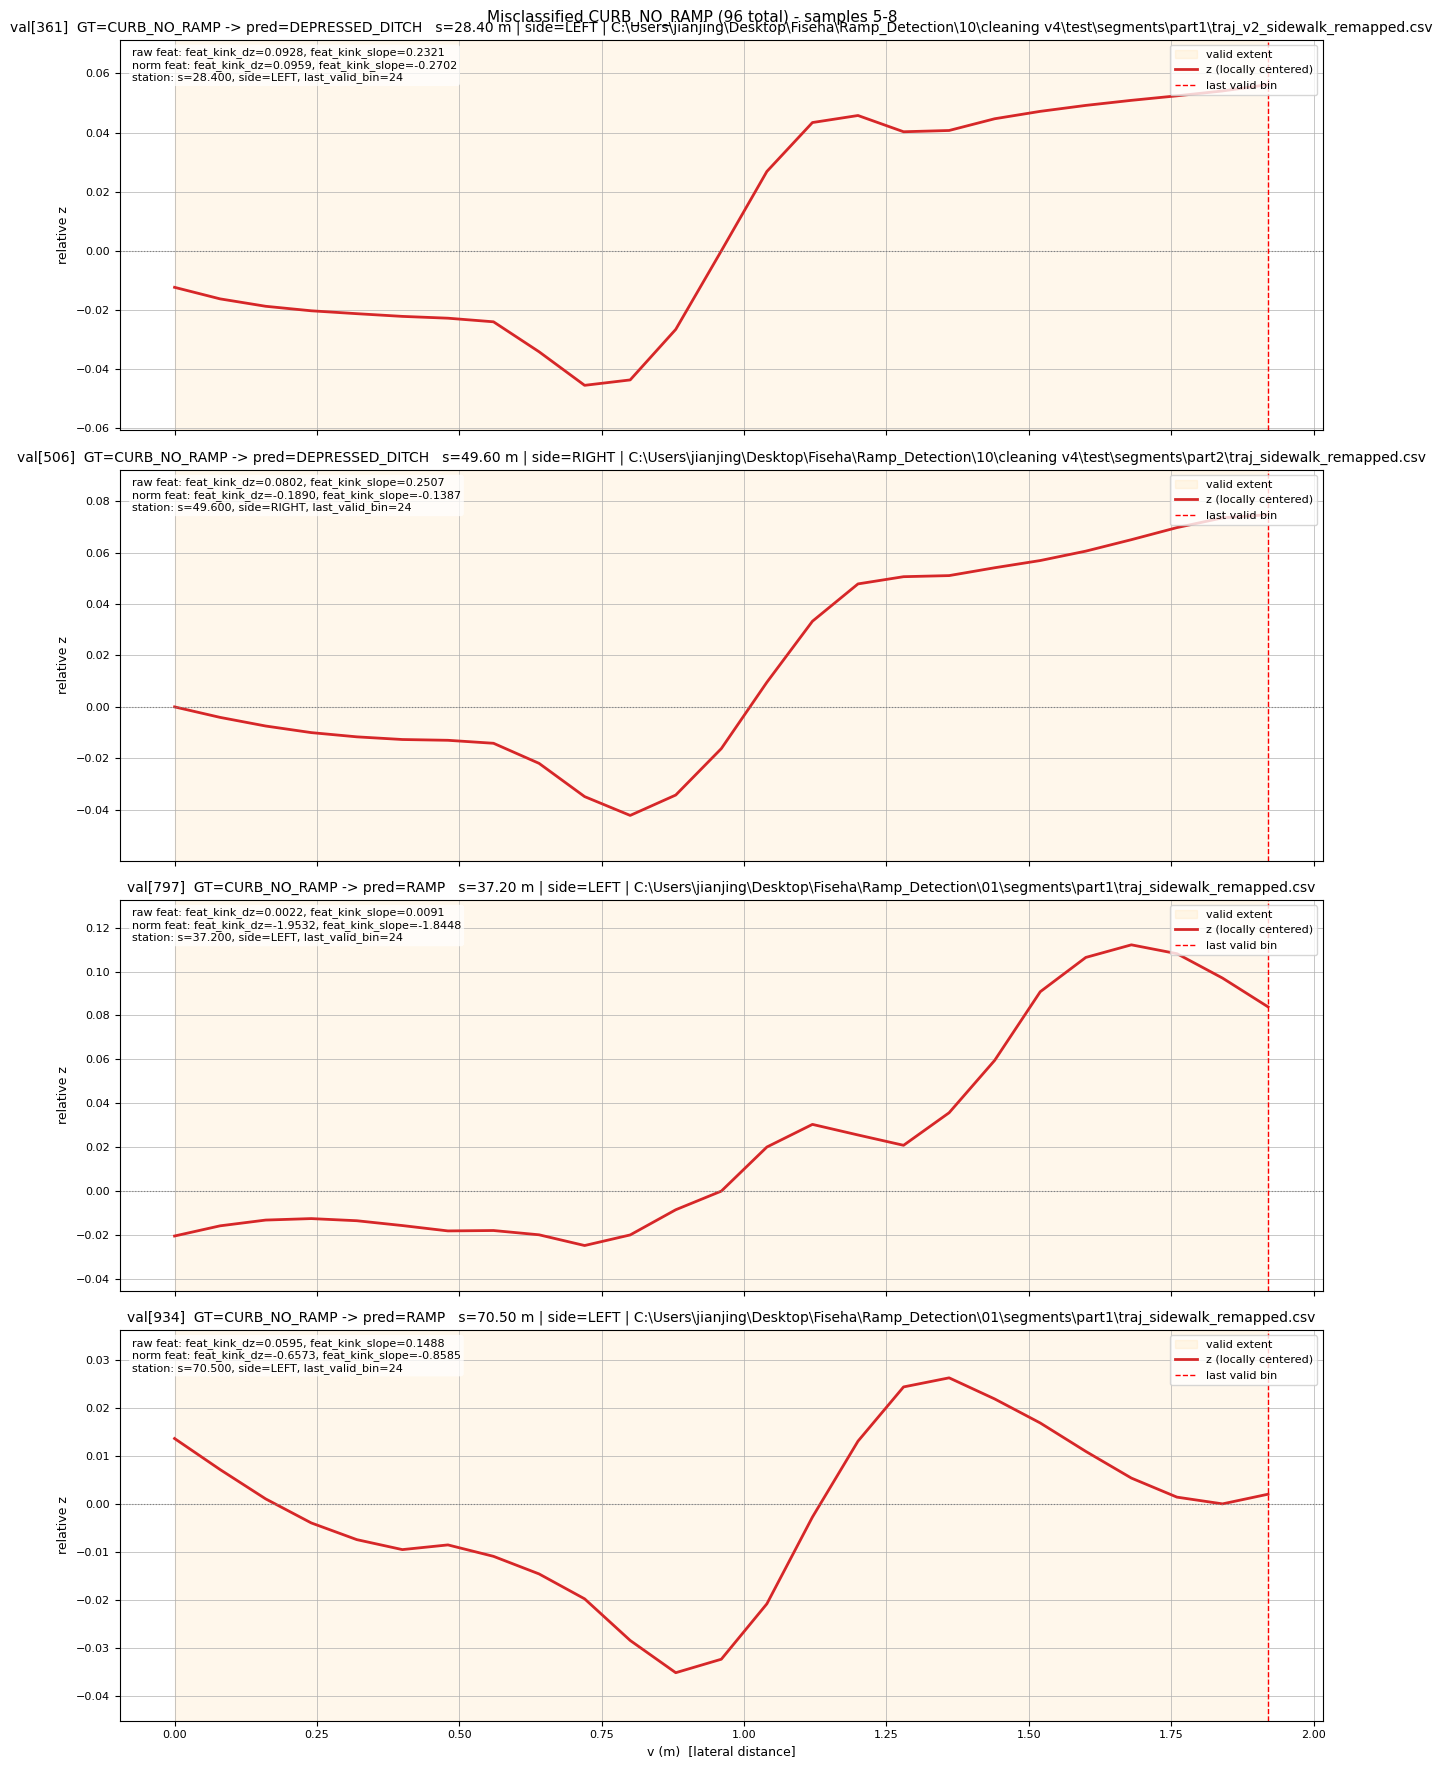

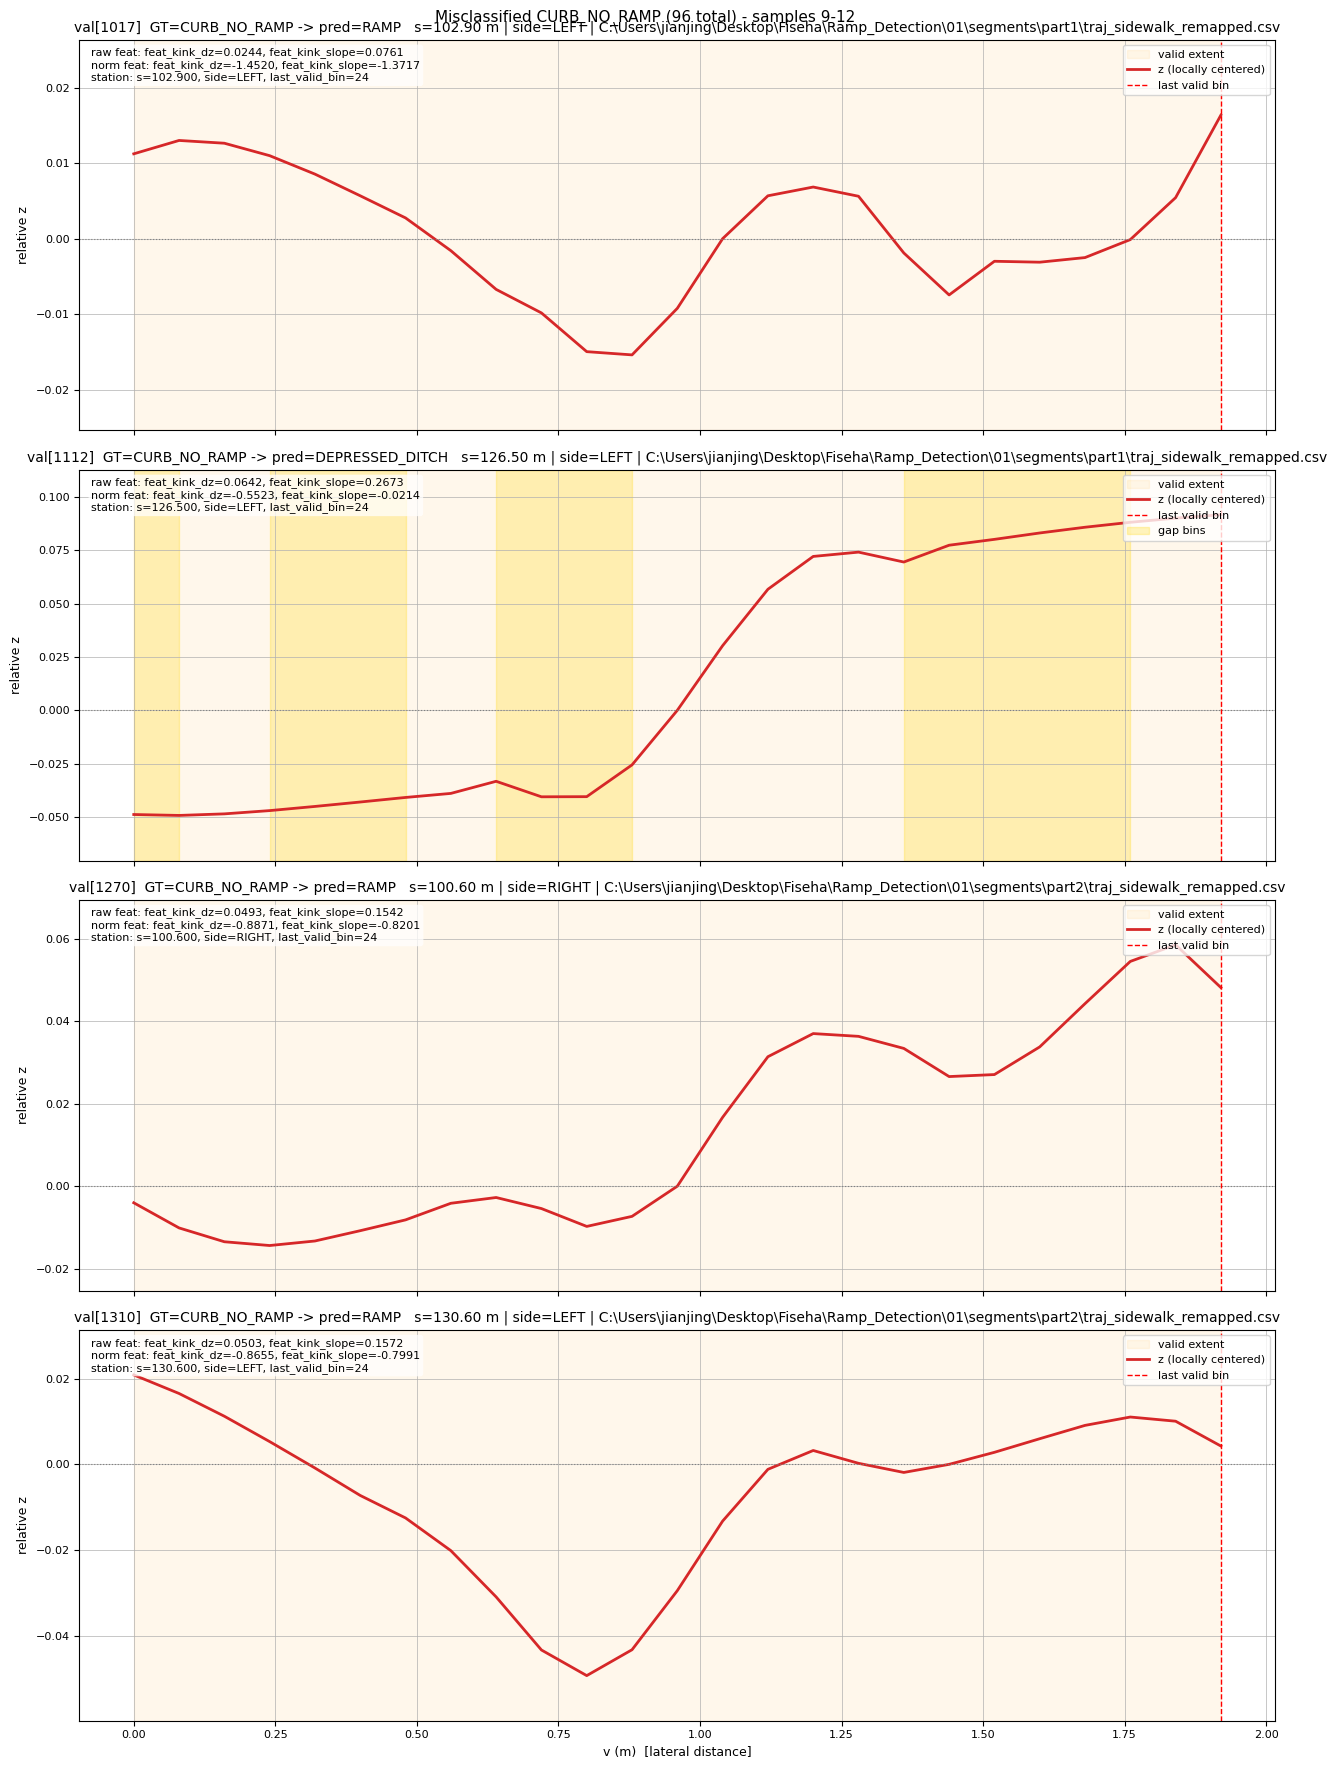

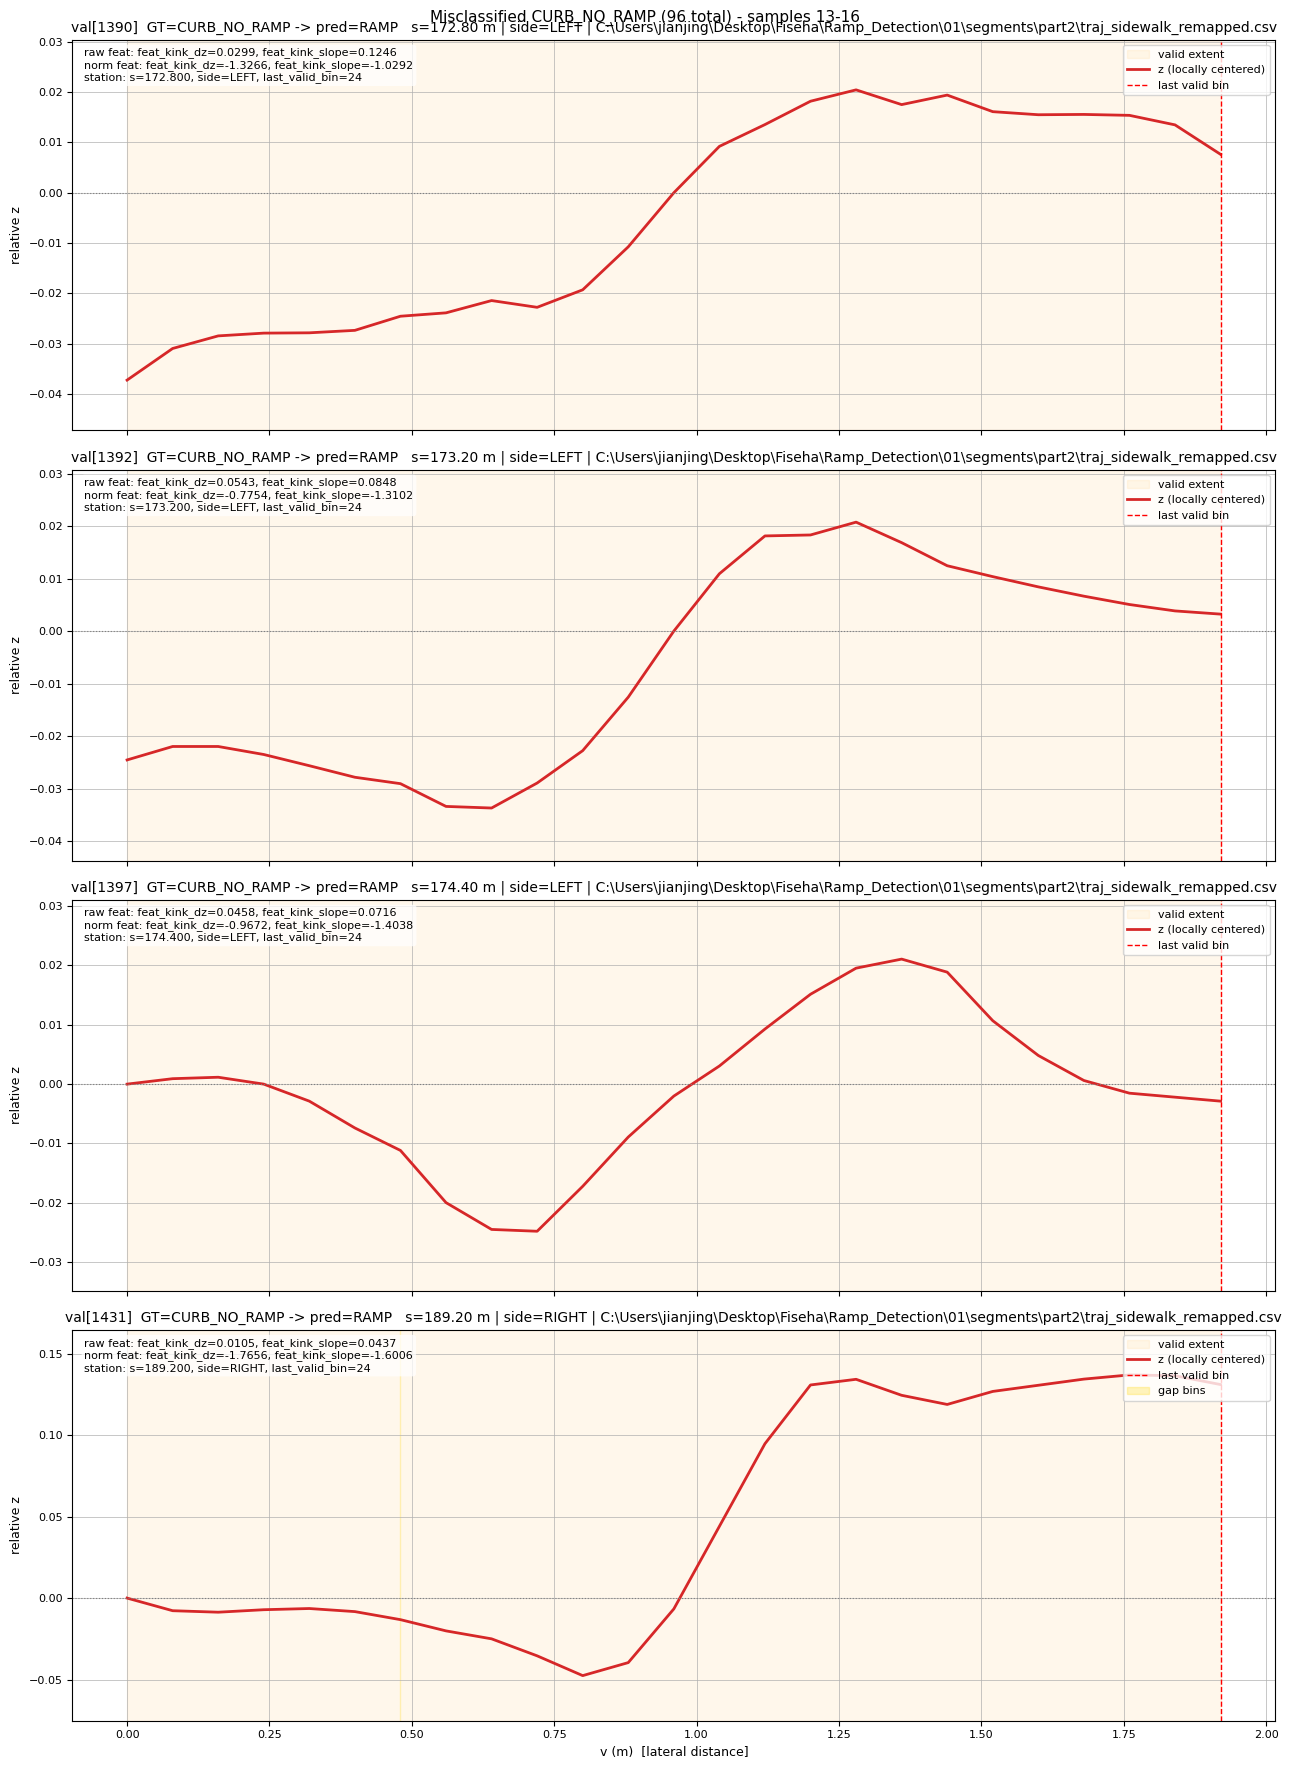

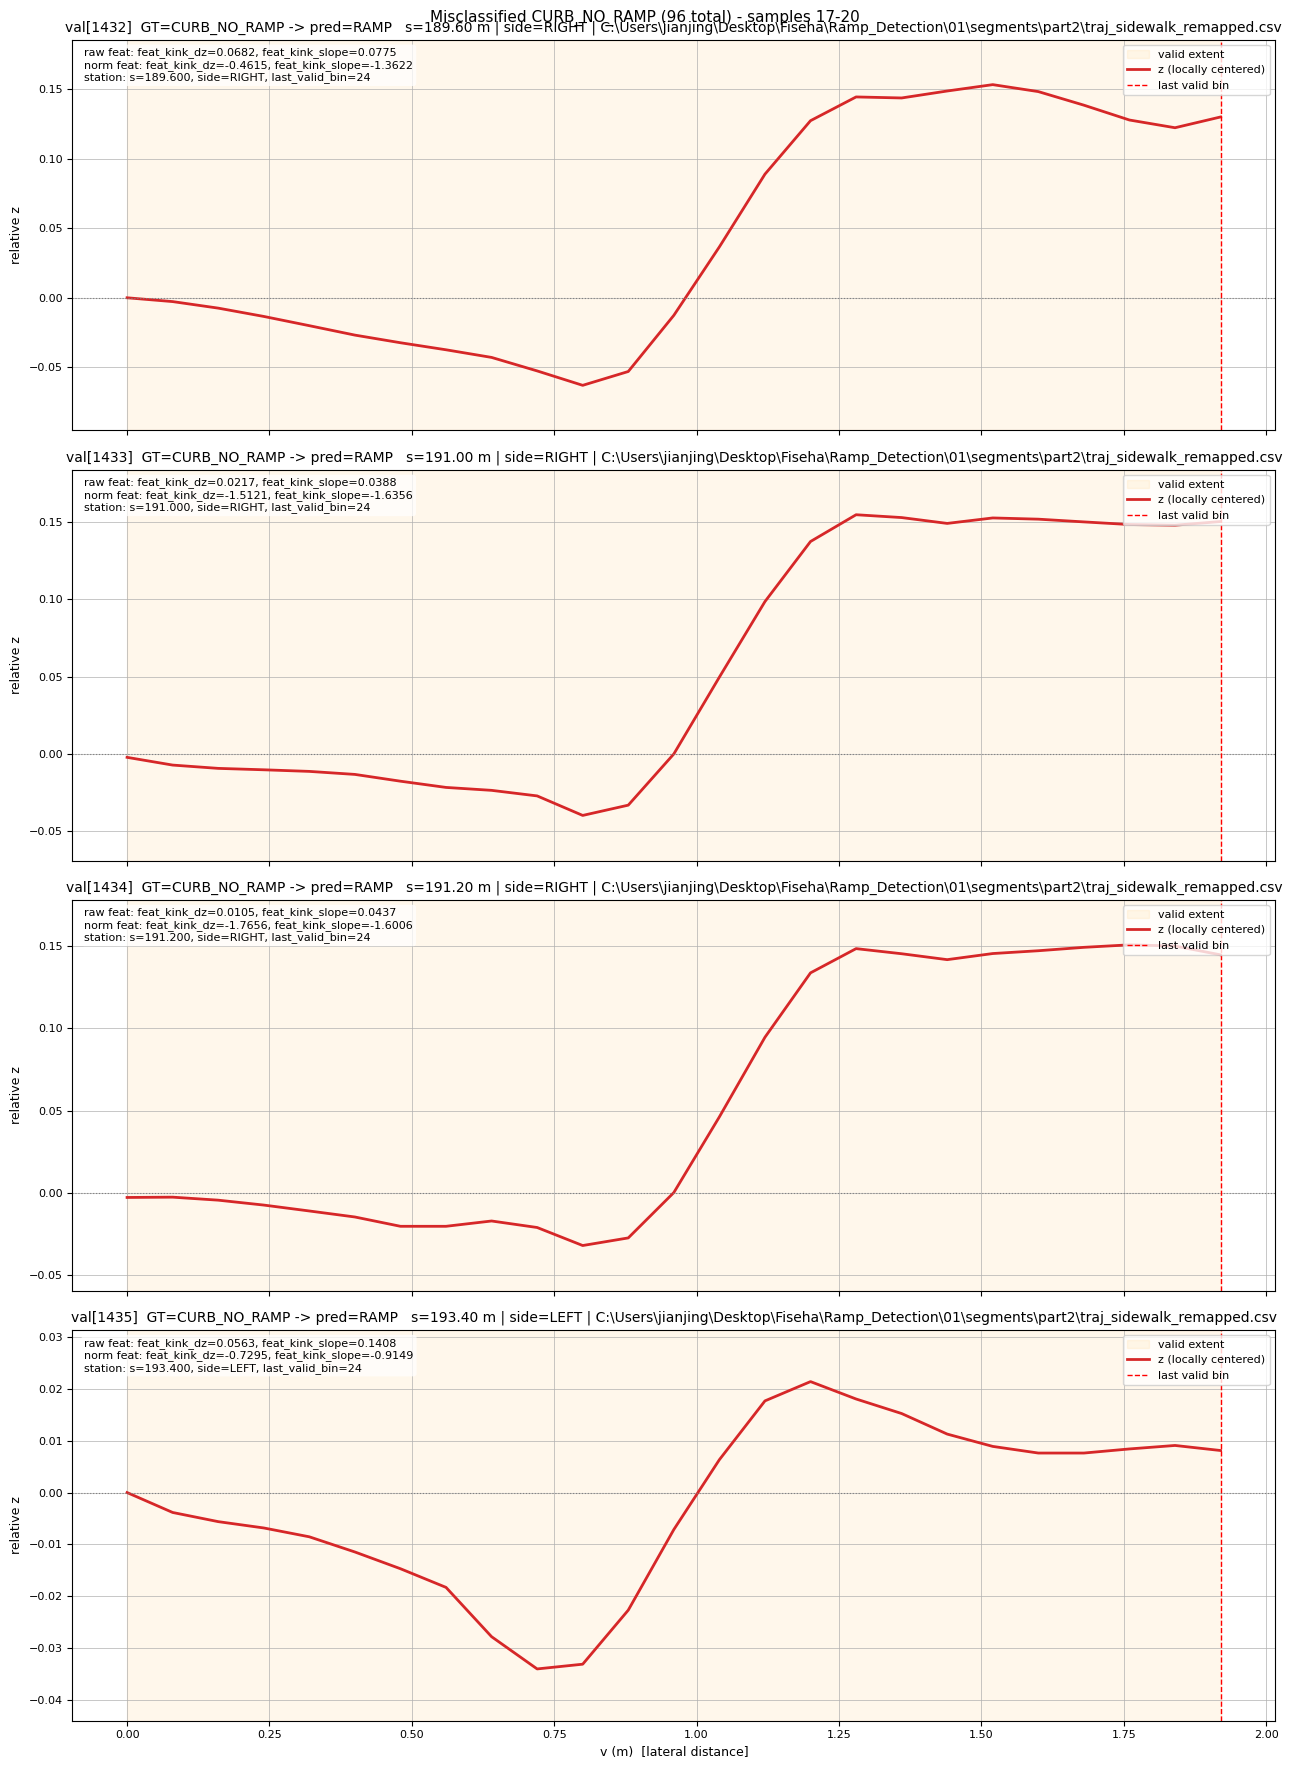

In [10]:

# ============================================================
# CELL 7b - Inspect Misclassified Samples For One GT Class
# ============================================================
GT_LABEL_TO_INSPECT = "CURB_NO_RAMP"   # choose from: RAMP, CURB_NO_RAMP, DEPRESSED_DITCH
GT_CLASS_INT = next(k for k, v in LABEL_MAP.items() if v == GT_LABEL_TO_INSPECT)
GT_IDX = CLASS_TO_INDEX[GT_CLASS_INT]
MAX_MISCLASSIFIED_PLOTS = 20   # cap how many profiles to draw
PLOTS_PER_FIGURE = 4           # rows per figure page so each subplot stays large

# Identify misclassified rows for the chosen ground-truth class in the validation set.
gt_mask = y_true == GT_IDX
wrong_mask = y_pred != GT_IDX
miss_idx = np.where(gt_mask & wrong_mask)[0]

print(f"GT={GT_LABEL_TO_INSPECT} in val     : {gt_mask.sum():,}")
print(f"Misclassified {GT_LABEL_TO_INSPECT} : {len(miss_idx):,}")

if len(miss_idx) == 0:
    print(f"No misclassified {GT_LABEL_TO_INSPECT} samples - nothing to plot.")
else:
    val_df_reset = val_df_final.reset_index(drop=True)
    v_axis = np.arange(N_BINS) * 0.08

    n_plot = min(len(miss_idx), MAX_MISCLASSIFIED_PLOTS)
    plot_indices = miss_idx[:n_plot]

    for page_start in range(0, n_plot, PLOTS_PER_FIGURE):
        page_indices = plot_indices[page_start: page_start + PLOTS_PER_FIGURE]
        n_rows = len(page_indices)
        fig, axes = plt.subplots(n_rows, 1, figsize=(13, 4.5 * n_rows), sharex=True)
        if n_rows == 1:
            axes = [axes]

        for ax, vi in zip(axes, page_indices):
            x_sample, x_feat_sample, _ = val_ds[vi]
            z_norm = x_sample[0].numpy()
            gap_ch = x_sample[1].numpy().astype(bool)
            pad_ch = x_sample[2].numpy().astype(bool)
            feat_norm = x_feat_sample.numpy()

            row = val_df_reset.iloc[vi]
            pred_label = INDEX_TO_LABEL[int(y_pred[vi])]
            s_val = row.get("s_m", float("nan"))
            side_val = row.get("side", "?")
            src_val = row.get("source_file", "?")
            last_valid_bin = int(row.get("last_valid_bin", -1))
            feat_raw = row[ACTIVE_FEATURE_COLS].to_numpy(dtype=float) if ACTIVE_FEATURE_COLS else np.array([], dtype=float)

            if last_valid_bin >= 0:
                valid_slice = slice(0, last_valid_bin + 1)
                z_valid = z_norm[valid_slice].copy()

                # Remove the local baseline so the profile shape is visible.
                z_center = z_valid - np.nanmedian(z_valid)

                z_plot = np.full(N_BINS, np.nan, dtype=float)
                z_plot[valid_slice] = z_center

                y_min = float(np.nanmin(z_center))
                y_max = float(np.nanmax(z_center))
                y_pad = max(0.01, 0.15 * max(y_max - y_min, 1e-6))

                ax.axvspan(0.0, v_axis[last_valid_bin], color="orange", alpha=0.08, label="valid extent")
                ax.plot(v_axis, z_plot, lw=2.0, color="tab:red", label="z (locally centered)")
                ax.axhline(0.0, color="gray", lw=0.8, ls=":")
                ax.axvline(v_axis[last_valid_bin], color="red", lw=1.0, ls="--", label="last valid bin")

                gap_regions = gap_ch & (~pad_ch)
                if gap_regions.any():
                    ax.fill_between(
                        v_axis,
                        y_min - y_pad,
                        y_max + y_pad,
                        where=gap_regions,
                        color="gold",
                        alpha=0.25,
                        label="gap bins",
                    )

                ax.set_ylim(y_min - y_pad, y_max + y_pad)
            else:
                ax.text(0.5, 0.5, "No valid bins", ha="center", va="center", transform=ax.transAxes)

            ax.set_title(
                f"val[{vi}]  GT={GT_LABEL_TO_INSPECT} -> pred={pred_label}   "
                f"s={s_val:.2f} m | side={side_val} | {src_val}",
                fontsize=10,
            )
            if ACTIVE_FEATURE_COLS:
                feat_lines = [
                    "raw feat: " + ", ".join(f"{name}={val:.4f}" for name, val in zip(ACTIVE_FEATURE_COLS, feat_raw)),
                    "norm feat: " + ", ".join(f"{name}={val:.4f}" for name, val in zip(ACTIVE_FEATURE_COLS, feat_norm)),
                ]
            else:
                feat_lines = ["scalar features disabled"]
            feat_text = "\n".join(feat_lines + [f"station: s={s_val:.3f}, side={side_val}, last_valid_bin={last_valid_bin}"])
            ax.text(0.01, 0.98, feat_text, transform=ax.transAxes, va="top", ha="left", fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, edgecolor="none"))
            ax.set_ylabel("relative z", fontsize=9)
            ax.tick_params(labelsize=8)
            ax.grid(True, linewidth=0.5)
            ax.legend(fontsize=8, loc="upper right")

        axes[-1].set_xlabel("v (m)  [lateral distance]", fontsize=9)
        page_end = page_start + n_rows
        fig.suptitle(
            f"Misclassified {GT_LABEL_TO_INSPECT} ({len(miss_idx)} total) - samples {page_start + 1}-{page_end}",
            fontsize=11,
        )
        plt.tight_layout()
        plt.show()


In [11]:
# ============================================================
# CELL 8 - Save Model and Metadata
# ============================================================
# Save the trained model weights and enough metadata to rebuild preprocessing later.
model_path = OUTPUT_DIR / "ramp_cnn_pytorch.pt"
meta_path = OUTPUT_DIR / "ramp_cnn_pytorch_meta.json"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_index": CLASS_TO_INDEX,
    "index_to_label": INDEX_TO_LABEL,
    "channels": CHANNELS,
    "use_scalar_features": USE_SCALAR_FEATURES,
    "feature_cols": ACTIVE_FEATURE_COLS,
    "available_feature_cols": FEATURE_COLS,
    "n_bins": N_BINS,
}, model_path)

meta = {
    "dataset_dir": str(DATASET_DIR),
    "train_dir": str(TRAIN_DIR),
    "val_dir": str(VAL_DIR),
    "dataset_glob": DATASET_GLOB,
    "train_dataset_files": [str(p.resolve()) for p in train_dataset_files],
    "val_dataset_files": [str(p.resolve()) for p in val_dataset_files],
    "n_train_dataset_files": len(train_dataset_files),
    "n_val_dataset_files": len(val_dataset_files),
    "output_dir": str(OUTPUT_DIR),
    "split_mode": SPLIT_MODE,
    "channels": CHANNELS,
    "use_scalar_features": USE_SCALAR_FEATURES,
    "feature_cols": ACTIVE_FEATURE_COLS,
    "available_feature_cols": FEATURE_COLS,
    "n_bins": N_BINS,
    "class_to_index": CLASS_TO_INDEX,
    "index_to_label": INDEX_TO_LABEL,
    "z_mean": z_mean,
    "z_std": z_std,
    "feat_mean": feat_mean.tolist(),
    "feat_std": feat_std.tolist(),
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "epochs_requested": EPOCHS,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "best_val_f1": float(best_val_f1),
    "validation_accuracy": float(val_eval_acc),
    "validation_macro_f1": float(val_eval_f1),
}
meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"Saved model -> {model_path}")
print(f"Saved meta  -> {meta_path}")


Saved model -> C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\pytorch_ramp_cnn_outputs\ramp_cnn_pytorch.pt
Saved meta  -> C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\training\all zones dataset trimmed\pytorch_ramp_cnn_outputs\ramp_cnn_pytorch_meta.json
